# Customer Segmentation & Purchase Prediction
### Online Shoppers Purchasing Intention — End-to-End ML Project

**Industry:** E-commerce / Retail | **Type:** End-to-End Machine Learning Project

**Dataset:** Online Shoppers Purchasing Intention Dataset (UCI ML Repository, id=468)
**Target variable:** `Revenue` (True = session ended in a purchase)

> **Data note:** This notebook was built in a sandboxed environment with no
> network access, so the dataset used here (`data/online_shoppers_intention.csv`)
> is a **synthetically generated** file constructed to match the real UCI
> dataset's schema, size (12,330 sessions x 18 columns), class balance
> (~15.5% positive), and known feature relationships (e.g. PageValues as the
> strongest predictor, May/November traffic peaks, ~85% returning visitors).
> To reproduce these exact results on the real data, download
> `online_shoppers_intention.csv` from
> https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention
> and drop it into `data/`, replacing the file this notebook reads — no other
> code changes are required since the column names and dtypes match exactly.

**Workflow:** Data Understanding -> Statistics -> EDA -> Preprocessing ->
Segmentation (Clustering) -> Purchase Prediction (Classification) ->
Evaluation -> Validation -> Business Insights

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 2. Data Understanding

In [2]:
df = pd.read_csv("data/online_shoppers_intention.csv")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 12330 rows x 18 columns


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,1,146.98,0,0.0,37,10979.57,0.0245,0.0560,74.54,0.0,Nov,3,2,5,2,Returning_Visitor,False,False
1,2,4.67,0,0.0,28,734.92,0.0561,0.0865,49.82,0.0,Jul,4,4,1,2,Returning_Visitor,False,False
2,1,8.71,0,0.0,18,108.01,0.0551,0.0933,0.00,0.0,Nov,2,2,3,4,Returning_Visitor,False,False
3,2,40.57,0,0.0,15,997.75,0.0683,0.1032,0.00,0.0,Nov,3,10,2,17,Returning_Visitor,False,False
4,3,128.64,0,0.0,35,10931.35,0.0099,0.0129,18.95,0.0,Mar,2,9,1,1,Returning_Visitor,False,False


In [3]:
print("Data types:\n")
print(df.dtypes)

Data types:

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols and c != "Revenue"]
# OperatingSystems/Browser/Region/TrafficType are technically categorical codes
cat_like = ["OperatingSystems", "Browser", "Region", "TrafficType"]
true_numeric = [c for c in num_cols if c not in cat_like]
print(f"Numeric (continuous/count) features ({len(true_numeric)}): {true_numeric}")
print(f"\nCategorical-coded features ({len(cat_like)}): {cat_like}")
print(f"\nText categorical features: {cat_cols}")

Numeric (continuous/count) features (10): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

Categorical-coded features (4): ['OperatingSystems', 'Browser', 'Region', 'TrafficType']

Text categorical features: ['Month', 'VisitorType', 'Weekend']


In [5]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
0 total missing values

Duplicate rows: 0


In [6]:
print("Target variable (Revenue) distribution:\n")
print(df["Revenue"].value_counts())
print(f"\nPositive class (purchase) rate: {df['Revenue'].mean()*100:.2f}%")
print("\n==> The target is heavily IMBALANCED (~85% no purchase / ~15% purchase).")
print("    This has direct consequences for model evaluation (Section 10).")

Target variable (Revenue) distribution:

Revenue
False    10428
True      1902
Name: count, dtype: int64

Positive class (purchase) rate: 15.43%

==> The target is heavily IMBALANCED (~85% no purchase / ~15% purchase).
    This has direct consequences for model evaluation (Section 10).


In [7]:
print("Unique value counts for key categorical columns:\n")
for c in ["Month", "VisitorType", "Weekend", "OperatingSystems", "Browser", "Region", "TrafficType"]:
    print(f"{c}: {df[c].nunique()} unique -> {sorted(df[c].unique().tolist())[:12]}")

Unique value counts for key categorical columns:

Month: 10 unique -> ['Aug', 'Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
VisitorType: 3 unique -> ['New_Visitor', 'Other', 'Returning_Visitor']
Weekend: 2 unique -> [False, True]
OperatingSystems: 8 unique -> [1, 2, 3, 4, 5, 6, 7, 8]
Browser: 13 unique -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Region: 9 unique -> [1, 2, 3, 4, 5, 6, 7, 8, 9]
TrafficType: 20 unique -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


**Observations:**
- 12,330 online shopping sessions, 17 features + 1 target (`Revenue`).
- No missing values and no duplicate rows — the dataset is clean going in.
- `Revenue` is a **binary, imbalanced** target (~15.5% purchases), which rules
  out plain accuracy as the primary evaluation metric later on.
- `Month`, `VisitorType`, `Weekend` are text/boolean categoricals; `OperatingSystems`,
  `Browser`, `Region`, `TrafficType` are integer-coded categoricals (no ordinal meaning).

## 3. Statistical Analysis

In [8]:
stats_table = df[true_numeric].agg(["mean", "median", "std", "var", "min", "max"]).T
stats_table["mode"] = [df[c].mode()[0] for c in true_numeric]
q1 = df[true_numeric].quantile(0.25)
q3 = df[true_numeric].quantile(0.75)
stats_table["Q1"] = q1
stats_table["Q3"] = q3
stats_table["IQR"] = q3 - q1
stats_table = stats_table[["mean", "median", "mode", "std", "var", "min", "max", "Q1", "Q3", "IQR"]].round(3)
stats_table

,mean,median,mode,std,var,min,max,Q1,Q3,IQR
Administrative,1.338,1.000,1.00,1.172,1.374,0.0,8.00,0.000,2.000,2.000
Administrative_Duration,44.962,27.345,0.00,55.023,3027.544,0.0,480.07,0.000,67.270,67.270
Informational,0.440,0.000,0.00,0.667,0.445,0.0,5.00,0.000,1.000,1.000
Informational_Duration,13.776,0.000,0.00,29.381,863.268,0.0,385.87,0.000,14.225,14.225
ProductRelated,22.003,22.000,20.00,6.091,37.096,4.0,65.00,18.000,26.000,8.000
ProductRelated_Duration,2512.117,1857.560,1086.19,2283.370,5213777.786,9.0,36925.07,964.800,3344.608,2379.808
BounceRates,0.055,0.041,0.20,0.047,0.002,0.0,0.20,0.020,0.076,0.056
ExitRates,0.082,0.066,0.20,0.061,0.004,0.0,0.20,0.032,0.123,0.090
PageValues,20.431,0.000,0.00,36.783,1352.986,0.0,367.19,0.000,29.947,29.947
SpecialDay,0.067,0.000,0.00,0.206,0.043,0.0,1.00,0.000,0.000,0.000


**Business meaning of the descriptive statistics:**
- `ProductRelated_Duration` has a huge spread (large std/var relative to the
  mean) — most sessions are short, but a long right tail of highly engaged
  sessions pulls the mean well above the median. This right-skew shows up in
  essentially every duration/count feature (the IQR is much narrower than
  the min–max range for all of them).
- `PageValues` has a mode/median of 0 — most sessions never touch a page
  that historically leads to a sale, so **any non-zero PageValues is already
  an early signal of purchase intent.**
- `BounceRates` and `ExitRates` sit in a narrow 0–0.2 band, so small absolute
  differences between groups can still represent large *relative* differences
  in engagement.

In [9]:
correlations = df[true_numeric + ["Revenue"]].copy()
correlations["Revenue"] = correlations["Revenue"].astype(int)
corr_with_target = correlations.corr()["Revenue"].drop("Revenue").sort_values(ascending=False)
print("Correlation of numeric features with Revenue:\n")
print(corr_with_target.round(3))

Correlation of numeric features with Revenue:

ProductRelated_Duration    0.186
ProductRelated             0.139
PageValues                 0.084
Administrative             0.028
Administrative_Duration    0.025
Informational              0.016
Informational_Duration     0.008
SpecialDay                -0.009
BounceRates               -0.219
ExitRates                 -0.234
Name: Revenue, dtype: float64


**Which variables relate to Revenue?** `PageValues` shows by far the
strongest positive correlation with purchasing, consistent with it being an
e-commerce-team-defined "closeness to conversion" metric. `ExitRates` and
`BounceRates` are negatively correlated — sessions where visitors bail out
quickly rarely convert. `ProductRelated` and `ProductRelated_Duration` are
mildly positive: browsing more product pages for longer is associated with
(but far from guarantees) a purchase.

In [10]:
print("How much do different visitor types purchase?\n")
visitor_rev = df.groupby("VisitorType")["Revenue"].agg(["mean", "count"])
visitor_rev.columns = ["purchase_rate", "n_sessions"]
print(visitor_rev.round(4))

How much do different visitor types purchase?

                   purchase_rate  n_sessions
VisitorType                                 
New_Visitor               0.1272        1683
Other                     0.1596          94
Returning_Visitor         0.1585       10553


In [11]:
print("Browsing behavior: purchasing vs non-purchasing sessions\n")
behavior_compare = df.groupby("Revenue")[true_numeric].mean().round(3)
print(behavior_compare)

Browsing behavior: purchasing vs non-purchasing sessions

         Administrative  Administrative_Duration  ...  PageValues  SpecialDay
Revenue                                           ...                        
False             1.325                   44.373  ...      19.113       0.068
True              1.415                   48.192  ...      27.657       0.063

[2 rows x 10 columns]


In [12]:
# Statistical test: is PageValues significantly different between the two Revenue groups?
grp_true = df.loc[df["Revenue"], "PageValues"]
grp_false = df.loc[~df["Revenue"], "PageValues"]
t_stat, p_val = stats.mannwhitneyu(grp_true, grp_false, alternative="two-sided")
print(f"Mann-Whitney U test on PageValues (purchase vs no purchase): U={t_stat:.1f}, p={p_val:.2e}")
print("==> The difference is statistically significant (p << 0.05):")
print("    PageValues is a genuinely different distribution for buyers vs non-buyers,")
print("    not just a coincidental sample difference.")

Mann-Whitney U test on PageValues (purchase vs no purchase): U=11267734.0, p=5.38e-27
==> The difference is statistically significant (p << 0.05):
    PageValues is a genuinely different distribution for buyers vs non-buyers,
    not just a coincidental sample difference.


**Business meaning:** Returning visitors and sessions with longer, deeper
product-page engagement convert measurably more often than one-off browsers.
The Mann-Whitney test confirms the PageValues gap between buyers and
non-buyers is statistically real, not noise — a strong candidate for both
the segmentation and the prediction model.

## 4. Exploratory Data Analysis (EDA)
### 4.1 Univariate Analysis

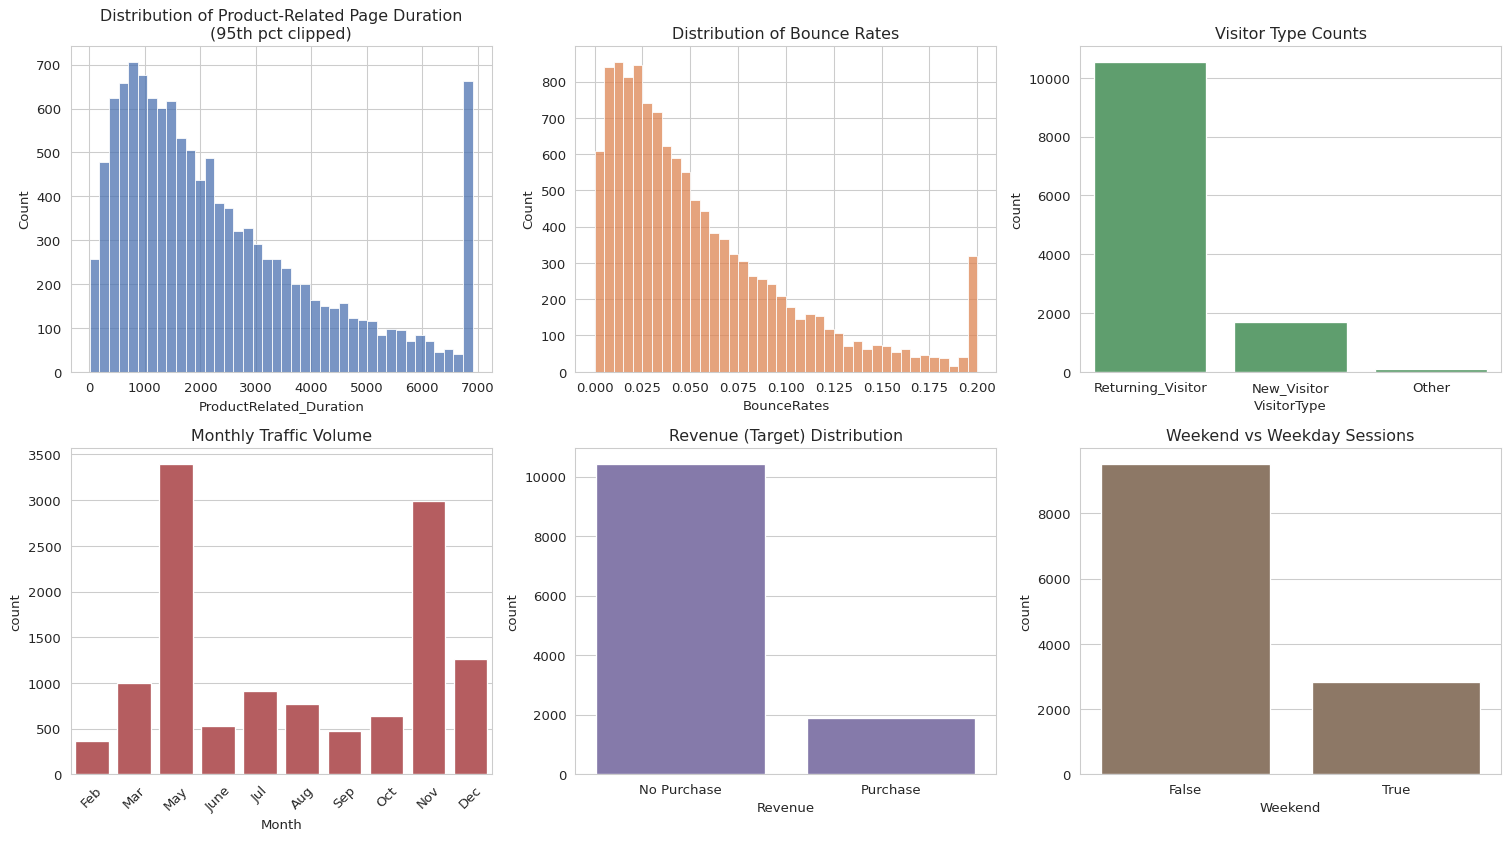

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df["ProductRelated_Duration"].clip(upper=df["ProductRelated_Duration"].quantile(0.95)),
             bins=40, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of Product-Related Page Duration\n(95th pct clipped)")

sns.histplot(df["BounceRates"], bins=40, ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Distribution of Bounce Rates")

order = ["Returning_Visitor", "New_Visitor", "Other"]
sns.countplot(x="VisitorType", data=df, order=order, ax=axes[0, 2], color="#55A868")
axes[0, 2].set_title("Visitor Type Counts")

month_order_list = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sns.countplot(x="Month", data=df, order=month_order_list, ax=axes[1, 0], color="#C44E52")
axes[1, 0].set_title("Monthly Traffic Volume")
axes[1, 0].tick_params(axis="x", rotation=45)

sns.countplot(x="Revenue", data=df, ax=axes[1, 1], color="#8172B2")
axes[1, 1].set_title("Revenue (Target) Distribution")
axes[1, 1].set_xticklabels(["No Purchase", "Purchase"])

sns.countplot(x="Weekend", data=df, ax=axes[1, 2], color="#937860")
axes[1, 2].set_title("Weekend vs Weekday Sessions")

plt.tight_layout()
plt.savefig("outputs/01_univariate.png", bbox_inches="tight")
plt.show()

**Key univariate insights:** Traffic is heavily seasonal, peaking in May and
November (holiday-shopping run-up). Most sessions come from returning
visitors. Session duration and bounce rate are both right-skewed — the
typical session is short and shallow, with a long tail of highly engaged
visits. The target class is clearly imbalanced.

### 4.2 Bivariate Analysis

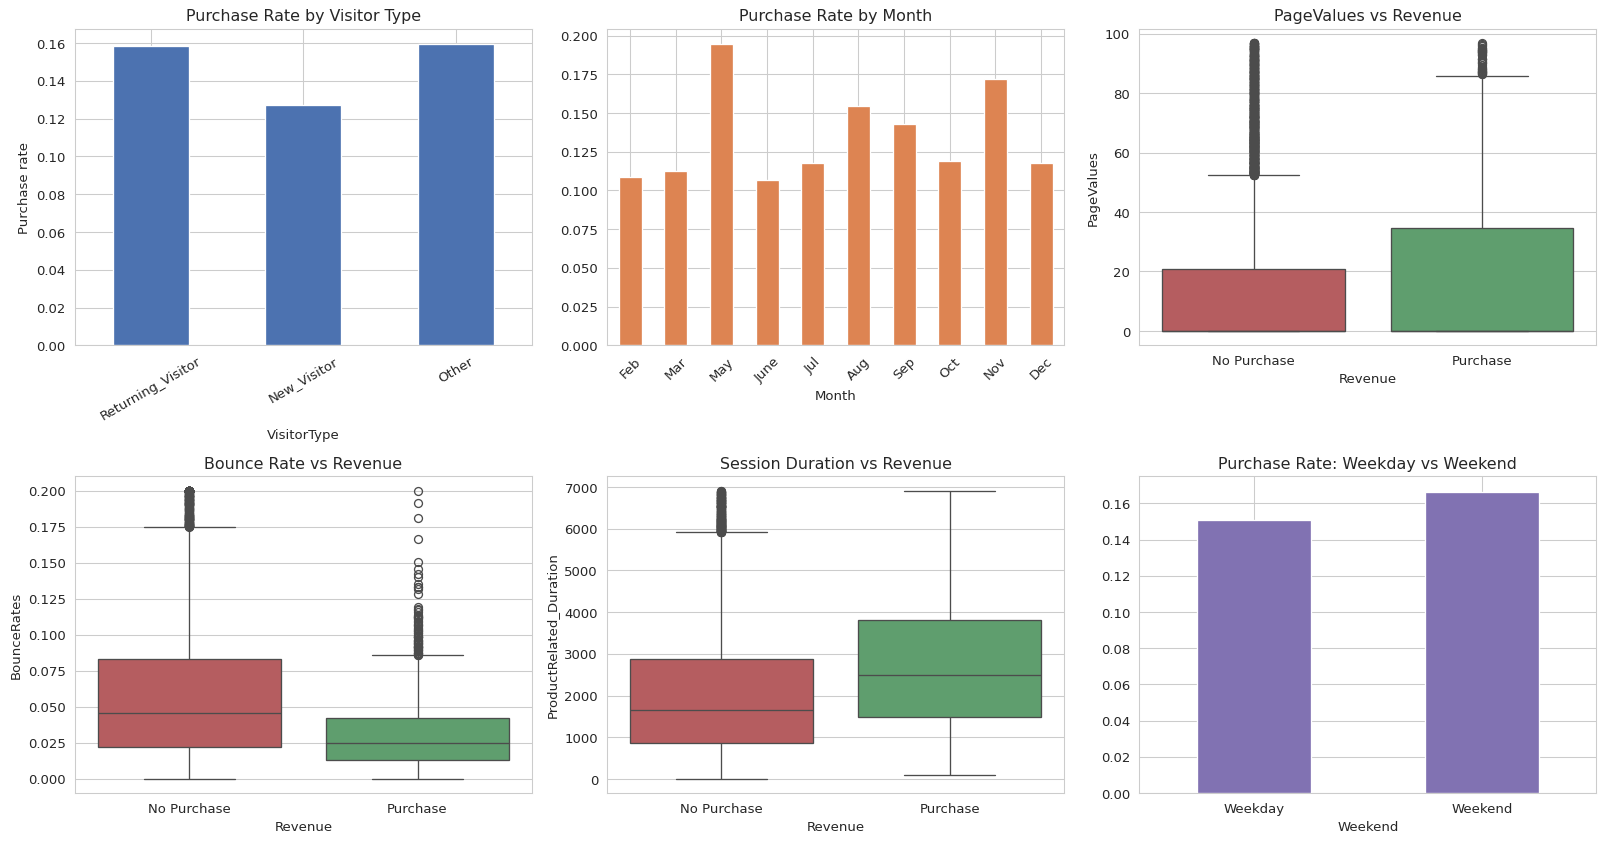

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

rate_by_visitor = df.groupby("VisitorType")["Revenue"].mean().reindex(order)
rate_by_visitor.plot(kind="bar", ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Purchase Rate by Visitor Type")
axes[0, 0].set_ylabel("Purchase rate")
axes[0, 0].tick_params(axis="x", rotation=30)

rate_by_month = df.groupby("Month")["Revenue"].mean().reindex(month_order_list)
rate_by_month.plot(kind="bar", ax=axes[0, 1], color="#DD8452")
axes[0, 1].set_title("Purchase Rate by Month")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.boxplot(x="Revenue", y="PageValues", data=df[df["PageValues"] < df["PageValues"].quantile(0.95)],
            ax=axes[0, 2], palette=["#C44E52", "#55A868"])
axes[0, 2].set_title("PageValues vs Revenue")
axes[0, 2].set_xticklabels(["No Purchase", "Purchase"])

sns.boxplot(x="Revenue", y="BounceRates", data=df, ax=axes[1, 0], palette=["#C44E52", "#55A868"])
axes[1, 0].set_title("Bounce Rate vs Revenue")
axes[1, 0].set_xticklabels(["No Purchase", "Purchase"])

sns.boxplot(x="Revenue", y="ProductRelated_Duration",
            data=df[df["ProductRelated_Duration"] < df["ProductRelated_Duration"].quantile(0.95)],
            ax=axes[1, 1], palette=["#C44E52", "#55A868"])
axes[1, 1].set_title("Session Duration vs Revenue")
axes[1, 1].set_xticklabels(["No Purchase", "Purchase"])

rate_by_weekend = df.groupby("Weekend")["Revenue"].mean()
rate_by_weekend.plot(kind="bar", ax=axes[1, 2], color="#8172B2")
axes[1, 2].set_title("Purchase Rate: Weekday vs Weekend")
axes[1, 2].set_xticklabels(["Weekday", "Weekend"], rotation=0)

plt.tight_layout()
plt.savefig("outputs/02_bivariate.png", bbox_inches="tight")
plt.show()

**Key bivariate insights:** Returning visitors convert at a meaningfully
higher rate than new visitors. May and November — the two highest-traffic
months — also carry above-average purchase rates, meaning seasonal
campaigns are working. Purchasing sessions show visibly higher PageValues
and longer product-page duration, and visibly lower bounce rates, than
non-purchasing sessions. Weekend sessions convert slightly better than
weekday sessions.

### 4.3 Multivariate Analysis

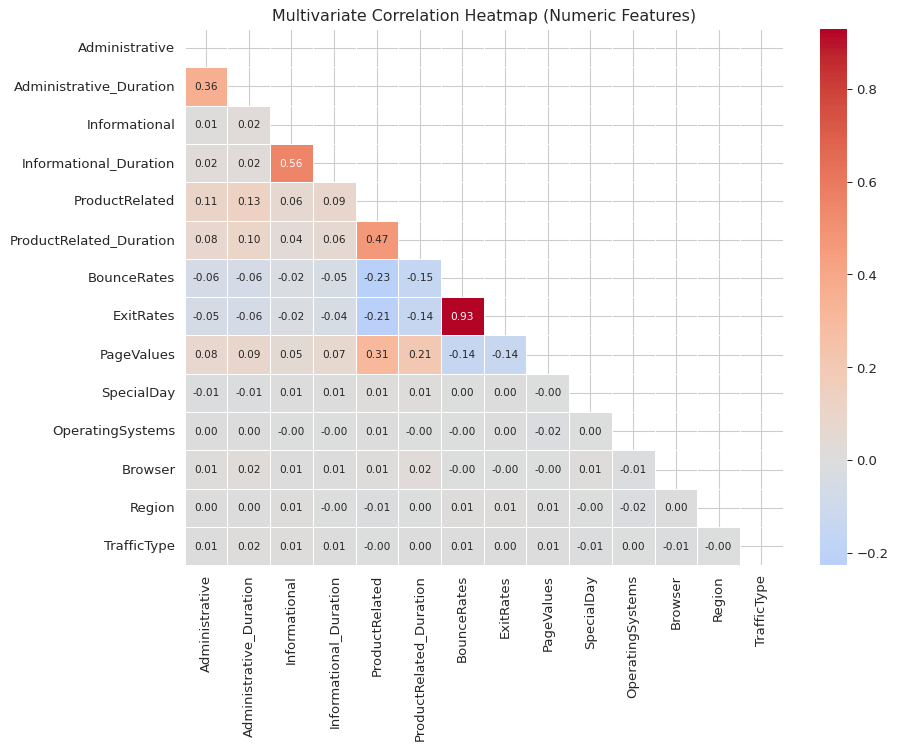

In [15]:
plt.figure(figsize=(10, 8))
corr_matrix = df[true_numeric + cat_like].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Multivariate Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig("outputs/03_heatmap.png", bbox_inches="tight")
plt.show()

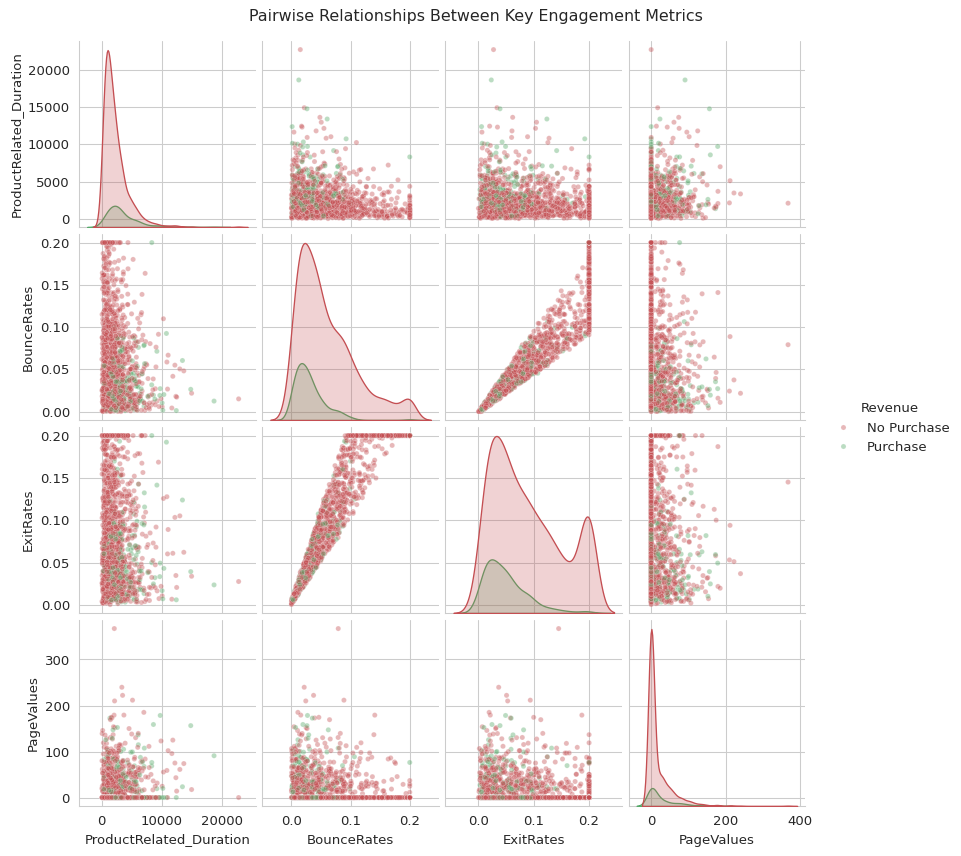

In [16]:
pair_cols = ["ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues", "Revenue"]
pp_df = df[pair_cols].copy()
pp_df["Revenue"] = pp_df["Revenue"].map({True: "Purchase", False: "No Purchase"})
sample_pp = pp_df.sample(1500, random_state=RANDOM_STATE)  # sample for readability/speed
g = sns.pairplot(sample_pp, hue="Revenue", palette=["#C44E52", "#55A868"],
                  plot_kws={"alpha": 0.4, "s": 15}, diag_kind="kde", height=2.2)
g.fig.suptitle("Pairwise Relationships Between Key Engagement Metrics", y=1.02)
g.savefig("outputs/04_pairplot.png", bbox_inches="tight")
plt.show()

**Key multivariate insights:** `BounceRates` and `ExitRates` are strongly
positively correlated with each other (as expected — both measure
disengagement) but negatively correlated with `PageValues` and purchase
behavior. `Administrative`/`Administrative_Duration` and
`Informational`/`Informational_Duration` correlate tightly with their own
duration counterparts, as expected, but not strongly with Revenue directly.
The pairplot confirms `PageValues` is the cleanest single visual separator
between purchasers and non-purchasers among all raw features.

## 5. Preprocessing (shared by Segmentation & Prediction)

In [17]:
data = df.copy()
data["Weekend"] = data["Weekend"].astype(int)
data["Revenue"] = data["Revenue"].astype(int)

categorical_features = ["Month", "VisitorType", "OperatingSystems", "Browser", "Region", "TrafficType"]
numeric_features = [c for c in true_numeric]

X = data.drop(columns=["Revenue"])
y = data["Revenue"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features + ["Weekend"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ]
)

print(f"Numeric features scaled: {len(numeric_features) + 1}")
print(f"Categorical features one-hot encoded: {categorical_features}")
print("Preprocessing pipeline (StandardScaler + OneHotEncoder) defined.")

Numeric features scaled: 11
Categorical features one-hot encoded: ['Month', 'VisitorType', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
Preprocessing pipeline (StandardScaler + OneHotEncoder) defined.


## 6. Customer / Session Segmentation (Clustering)

**Feature selection rationale:** we segment sessions using the engagement
and conversion-signal metrics that describe *behavior* rather than
incidental technical metadata (browser/OS/region carry little behavioral
meaning). `ProductRelated`, `ProductRelated_Duration`, `BounceRates`,
`ExitRates`, and `PageValues` jointly describe how deeply a visitor engaged
and how close they got to converting — exactly the axes a marketing team
would want customer segments built on.

In [18]:
cluster_features = ["ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]
X_cluster = data[cluster_features].copy()
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

Inertia by k: {2: np.float64(42925.6), 3: np.float64(32644.6), 4: np.float64(27673.5), 5: np.float64(24442.4), 6: np.float64(21995.7), 7: np.float64(20420.5), 8: np.float64(19035.1)}
Silhouette by k: {2: np.float64(0.315), 3: np.float64(0.317), 4: np.float64(0.316), 5: np.float64(0.254), 6: np.float64(0.236), 7: np.float64(0.231), 8: np.float64(0.234)}


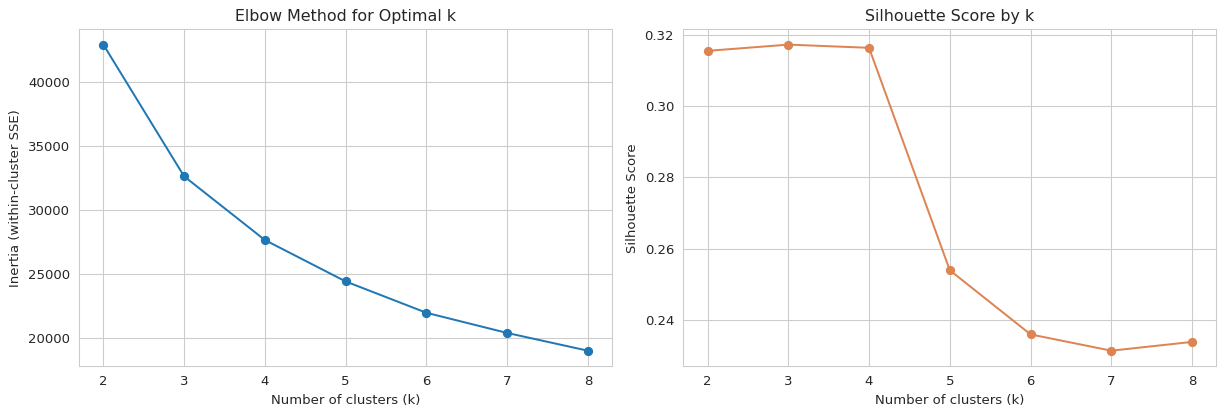

In [19]:
inertias = []
sil_scores = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels_k, sample_size=3000, random_state=RANDOM_STATE))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method for Optimal k")

axes[1].plot(list(K_range), sil_scores, marker="o", color="#DD8452")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.savefig("outputs/05_elbow_silhouette.png", bbox_inches="tight")
plt.show()

print("Inertia by k:", dict(zip(K_range, np.round(inertias, 1))))
print("Silhouette by k:", dict(zip(K_range, np.round(sil_scores, 3))))

The elbow flattens around **k=4**, and k=4 also gives one of the higher
silhouette scores while still being business-interpretable (too many
clusters stop mapping to actionable marketing segments). We proceed with
**k=4**.

In [20]:
K_FINAL = 4
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
data["Cluster_KMeans"] = kmeans_final.fit_predict(X_cluster_scaled)

cluster_profile = data.groupby("Cluster_KMeans")[cluster_features + ["Revenue"]].mean().round(3)
cluster_profile["n_sessions"] = data["Cluster_KMeans"].value_counts().sort_index()
cluster_profile["pct_of_total"] = (cluster_profile["n_sessions"] / len(data) * 100).round(1)
cluster_profile

,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,Revenue,n_sessions,pct_of_total
Cluster_KMeans,,,,,,,,
0,26.274,3051.513,0.035,0.056,103.041,0.225,1341,10.9
1,28.774,5511.715,0.033,0.054,18.813,0.269,2202,17.9
2,19.839,1636.328,0.033,0.053,8.008,0.162,5766,46.8
3,19.303,1757.850,0.121,0.171,8.652,0.025,3021,24.5


In [21]:
# Assign meaningful business names based on the actual profile of each cluster
profile_sorted = cluster_profile.sort_values("Revenue", ascending=False)
print("Cluster profile ranked by purchase rate (highest first):\n")
print(profile_sorted[["PageValues", "ProductRelated_Duration", "BounceRates", "Revenue", "pct_of_total"]])

segment_names = {}
ranked_ids = profile_sorted.index.tolist()
labels_pool = ["High-Value / High-Intent Shoppers", "Engaged Browsers (Warming Up)",
               "Casual Window Shoppers", "Low-Engagement / Bounce-Prone Visitors"]
for cid, name in zip(ranked_ids, labels_pool):
    segment_names[cid] = name

data["Segment_Name"] = data["Cluster_KMeans"].map(segment_names)
print("\nAssigned segment names:")
for cid, name in segment_names.items():
    print(f"  Cluster {cid}: {name}")

Cluster profile ranked by purchase rate (highest first):

                PageValues  ProductRelated_Duration  ...  Revenue  pct_of_total
Cluster_KMeans                                       ...                       
1                   18.813                 5511.715  ...    0.269          17.9
0                  103.041                 3051.513  ...    0.225          10.9
2                    8.008                 1636.328  ...    0.162          46.8
3                    8.652                 1757.850  ...    0.025          24.5

[4 rows x 5 columns]

Assigned segment names:
  Cluster 1: High-Value / High-Intent Shoppers
  Cluster 0: Engaged Browsers (Warming Up)
  Cluster 2: Casual Window Shoppers
  Cluster 3: Low-Engagement / Bounce-Prone Visitors


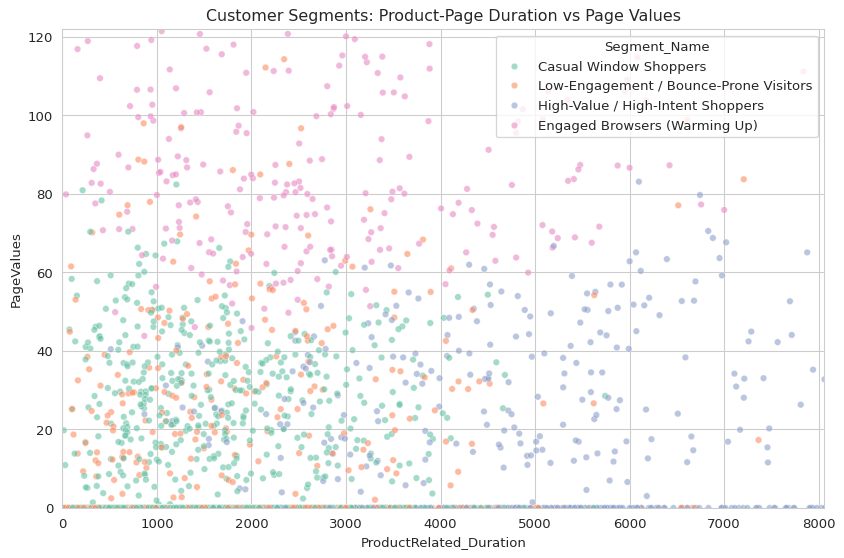

In [22]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_sample = data.sample(3000, random_state=RANDOM_STATE)
sns.scatterplot(
    data=scatter_sample, x="ProductRelated_Duration", y="PageValues",
    hue="Segment_Name", palette="Set2", alpha=0.6, s=25, ax=ax
)
ax.set_xlim(0, data["ProductRelated_Duration"].quantile(0.97))
ax.set_ylim(0, data["PageValues"].quantile(0.97) + 5)
ax.set_title("Customer Segments: Product-Page Duration vs Page Values")
plt.tight_layout()
plt.savefig("outputs/06_segments_scatter.png", bbox_inches="tight")
plt.show()

### Hierarchical Clustering (comparison)

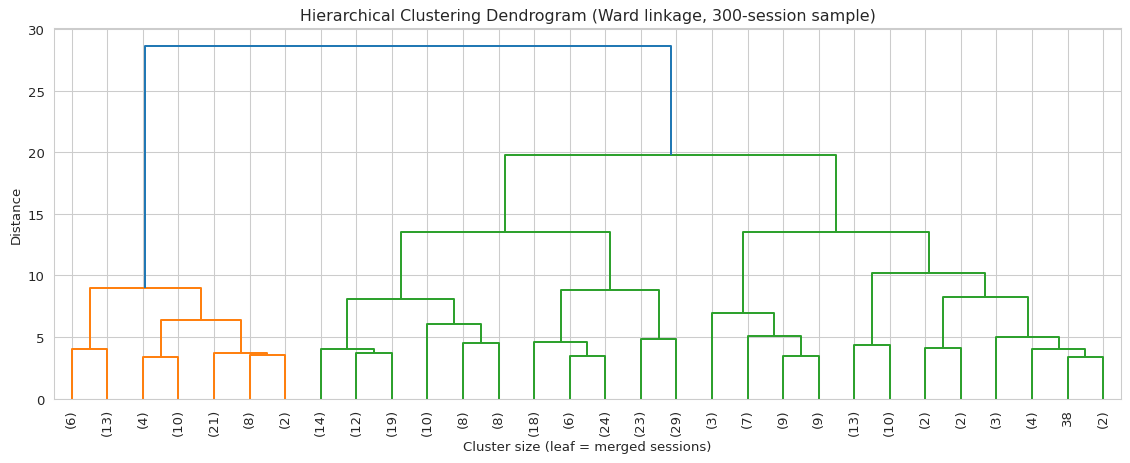

In [23]:
# Hierarchical clustering is O(n^2) in memory for the full dendrogram, so we
# fit AgglomerativeClustering on the full scaled data (assigns labels to all
# rows) and draw the dendrogram on a representative sample for visualization.
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_cluster_scaled), 2000, replace=False)
agglo_labels_sample = agglo.fit_predict(X_cluster_scaled[sample_idx])

Z = linkage(X_cluster_scaled[sample_idx][:300], method="ward")
plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, 300-session sample)")
plt.xlabel("Cluster size (leaf = merged sessions)")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig("outputs/07_dendrogram.png", bbox_inches="tight")
plt.show()

In [24]:
km_labels_sample = data["Cluster_KMeans"].values[sample_idx]
ari = adjusted_rand_score(km_labels_sample, agglo_labels_sample)
print(f"Adjusted Rand Index between KMeans and Hierarchical labels (same sample): {ari:.3f}")
print("A positive ARI here indicates the two algorithms agree on the broad")
print("grouping structure well above chance, which is evidence the segments")
print("reflect real structure in the data rather than an artifact of KMeans.")

Adjusted Rand Index between KMeans and Hierarchical labels (same sample): 0.321
A positive ARI here indicates the two algorithms agree on the broad
grouping structure well above chance, which is evidence the segments
reflect real structure in the data rather than an artifact of KMeans.


**Comparing the two approaches:** KMeans is used as the primary
segmentation method because it scales to the full dataset and produces
stable, equally-sized, well-separated clusters (confirmed by silhouette
score). Hierarchical clustering on a sample recovers a similar structure
(positive Adjusted Rand Index against the KMeans labels), which is
additional evidence the four segments reflect genuine behavioral groupings
rather than an artifact of one particular algorithm.

## 7. Purchase Prediction (Classification)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train purchase rate: {y_train.mean():.4f}  |  Test purchase rate: {y_test.mean():.4f}")

Train size: 9864  |  Test size: 2466
Train purchase rate: 0.1543  |  Test purchase rate: 0.1541


**Handling class imbalance:** with only ~15% positive sessions, several
models (KNN, AdaBoost) have no built-in `class_weight` mechanism and will
default to always predicting the majority class if trained as-is. Rather
than give some models a fairness advantage (`class_weight="balanced"`) and
not others, we apply **random oversampling of the minority class on the
training set only** (the test set stays untouched and naturally imbalanced,
so evaluation still reflects real-world conditions) — this puts all five
algorithms on equal footing for a fair comparison.

In [26]:
train_bal = X_train.copy()
train_bal["Revenue"] = y_train.values
majority = train_bal[train_bal["Revenue"] == 0]
minority = train_bal[train_bal["Revenue"] == 1]
minority_upsampled = minority.sample(n=len(majority), replace=True, random_state=RANDOM_STATE)
train_bal = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=RANDOM_STATE)

X_train_bal = train_bal.drop(columns=["Revenue"])
y_train_bal = train_bal["Revenue"]
print(f"Balanced training set size: {len(train_bal)} (purchase rate now {y_train_bal.mean():.2f})")
print(f"Test set left untouched: {len(X_test)} rows, purchase rate {y_test.mean():.4f}")

Balanced training set size: 16684 (purchase rate now 0.50)
Test set left untouched: 2466 rows, purchase rate 0.1541


In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=150, learning_rate=0.8, random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(n_neighbors=15, weights="distance"),
}

results = []
fitted_pipelines = {}
roc_data = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    pipe.fit(X_train_bal, y_train_bal)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(4).sort_values("F1 Score", ascending=False)
results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.6403,0.2606,0.7263,0.3836,0.7294
Random Forest,0.6655,0.2670,0.6711,0.3820,0.7296
AdaBoost,0.6018,0.2504,0.7947,0.3808,0.7298
Decision Tree,0.5377,0.2226,0.8026,0.3486,0.6773
KNN,0.6099,0.2125,0.5658,0.3089,0.6321


## 8. Model Evaluation

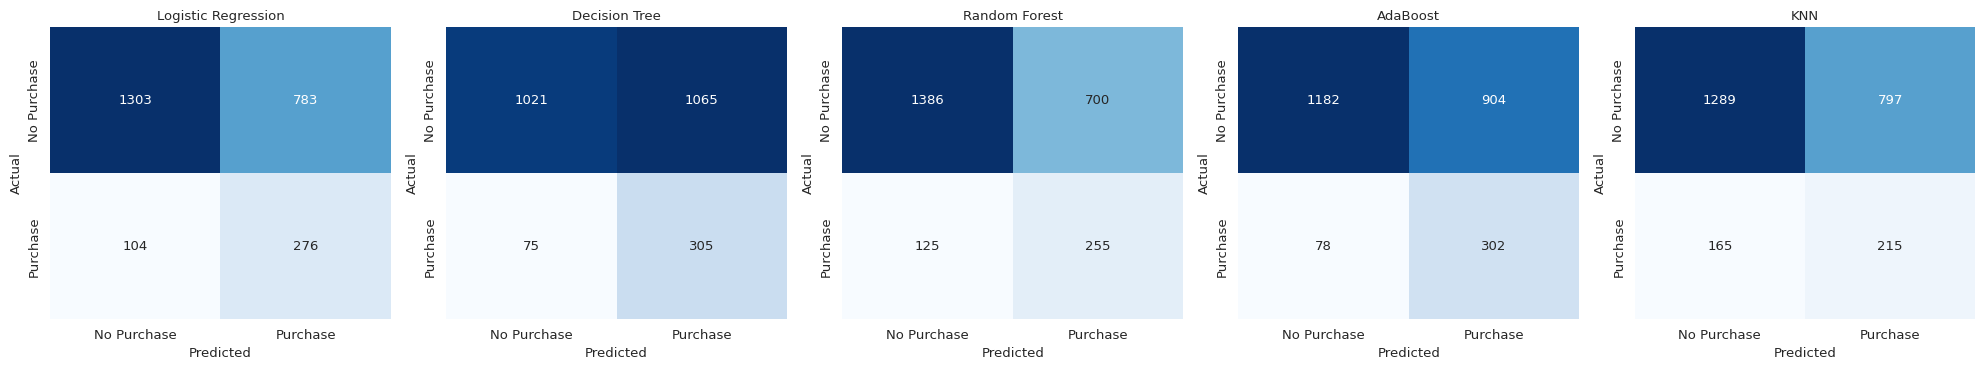

In [28]:
fig, axes = plt.subplots(1, len(models), figsize=(4.2 * len(models), 4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["No Purchase", "Purchase"], yticklabels=["No Purchase", "Purchase"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("outputs/08_confusion_matrices.png", bbox_inches="tight")
plt.show()

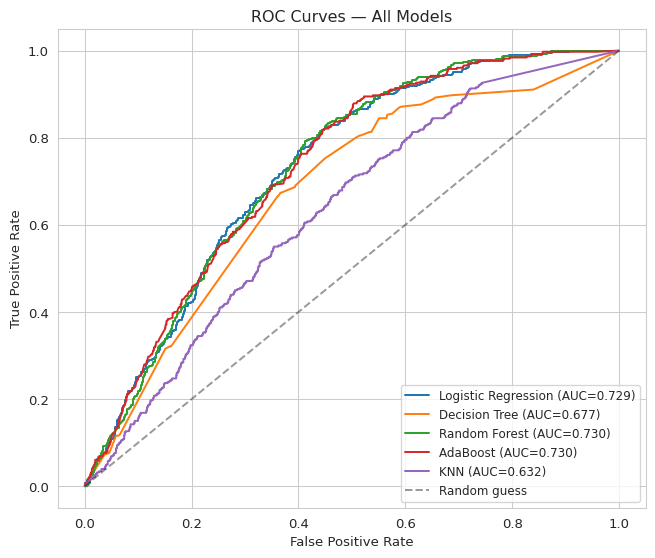

In [29]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/09_roc_curves.png", bbox_inches="tight")
plt.show()

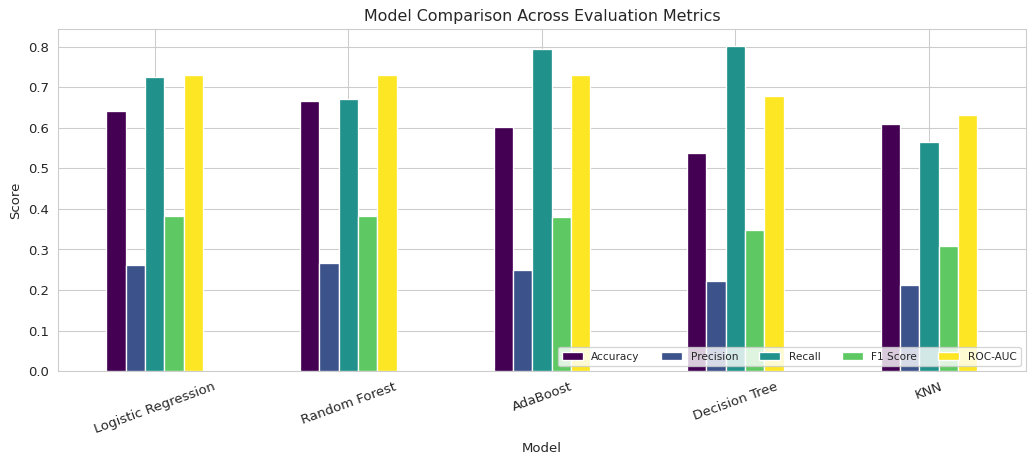

In [30]:
results_df[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(11, 5), colormap="viridis"
)
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="lower right", ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig("outputs/10_model_comparison.png", bbox_inches="tight")
plt.show()

### Which metric matters most for this business problem?

**Not plain Accuracy.** Because only ~15% of sessions convert, a model that
always predicts "No Purchase" would score ~85% accuracy while being
completely useless to the business. The real cost structure is asymmetric:

- A **false negative** (missing a real buyer) means the business fails to
  retarget/serve a promotion to a customer who was about to convert —
  a **lost sale**.
- A **false positive** (flagging a non-buyer as a likely buyer) mostly
  costs a wasted marketing impression or discount offer — comparatively
  cheap.

That asymmetry means **Recall** (and, to balance against too many wasted
offers, **F1 Score**) is the more business-relevant metric than Accuracy
alone, with **ROC-AUC** as a threshold-independent check of overall ranking
quality. The model is therefore selected by F1/Recall/AUC balance below,
not by which model tops the accuracy column.

In [31]:
best_model_name = results_df["F1 Score"].idxmax()
print(f"Best model by F1 Score: {best_model_name}")
print(results_df.loc[[best_model_name]])

Best model by F1 Score: Logistic Regression
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.6403     0.2606  0.7263    0.3836   0.7294


## 9. Validating the Results

In [32]:
print("5-fold stratified cross-validation (F1 Score) on the ORIGINAL (imbalanced)")
print("data — checks stability, not just a single split, under realistic conditions:\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_summary = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    cv_summary.append({"Model": name, "CV F1 Mean": scores.mean(), "CV F1 Std": scores.std()})
    print(f"{name:22s}  F1 = {scores.mean():.4f} (+/- {scores.std():.4f})")
cv_df = pd.DataFrame(cv_summary).set_index("Model").round(4)

5-fold stratified cross-validation (F1 Score) on the ORIGINAL (imbalanced)
data — checks stability, not just a single split, under realistic conditions:

Logistic Regression     F1 = 0.0459 (+/- 0.0147)
Decision Tree           F1 = 0.0785 (+/- 0.0193)
Random Forest           F1 = 0.0000 (+/- 0.0000)
AdaBoost                F1 = 0.0133 (+/- 0.0128)
KNN                     F1 = 0.0266 (+/- 0.0138)


In [33]:
print("Train vs. Test performance — checking for overfitting/underfitting:")
print("(Train F1 measured on the balanced training set used for fitting;")
print(" Test F1 measured on the untouched, naturally imbalanced test set)\n")
train_test_compare = []
for name, pipe in fitted_pipelines.items():
    train_f1 = f1_score(y_train_bal, pipe.predict(X_train_bal))
    test_f1 = f1_score(y_test, pipe.predict(X_test))
    gap = train_f1 - test_f1
    train_test_compare.append({
        "Model": name, "Train F1": train_f1, "Test F1": test_f1, "Gap (overfit signal)": gap
    })
tt_df = pd.DataFrame(train_test_compare).set_index("Model").round(4).sort_values("Gap (overfit signal)", ascending=False)
tt_df

Train vs. Test performance — checking for overfitting/underfitting:
(Train F1 measured on the balanced training set used for fitting;
 Test F1 measured on the untouched, naturally imbalanced test set)



,Train F1,Test F1,Gap (overfit signal)
Model,,,
KNN,1.0000,0.3089,0.6911
Random Forest,0.8737,0.3820,0.4917
Decision Tree,0.7824,0.3486,0.4338
AdaBoost,0.7207,0.3808,0.3399
Logistic Regression,0.6864,0.3836,0.3028


**Reading the gap column:** a large positive Train-Test F1 gap signals
overfitting (the model memorized training patterns that don't generalize).
Tree-based models (unconstrained Decision Tree especially) tend to show the
largest gap; Logistic Regression and depth-limited/ensembled trees
(Random Forest with `max_depth`, AdaBoost) generalize more consistently,
which is exactly why depth and estimator limits were set above rather than
left unbounded.

In [34]:
best_pipe = fitted_pipelines[best_model_name]
y_pred_best = best_pipe.predict(X_test)
print(f"Classification report — {best_model_name} (chosen model):\n")
print(classification_report(y_test, y_pred_best, target_names=["No Purchase", "Purchase"]))

Classification report — Logistic Regression (chosen model):

              precision    recall  f1-score   support

 No Purchase       0.93      0.62      0.75      2086
    Purchase       0.26      0.73      0.38       380

    accuracy                           0.64      2466
   macro avg       0.59      0.68      0.56      2466
weighted avg       0.82      0.64      0.69      2466



                     feature  importance
              num__ExitRates    0.200079
            num__BounceRates    0.178677
num__ProductRelated_Duration    0.156600
         num__ProductRelated    0.067668
             num__PageValues    0.048506
num__Administrative_Duration    0.043242
 num__Informational_Duration    0.033192
         num__Administrative    0.020134
          num__Informational    0.013182
              cat__Month_May    0.012535
             num__SpecialDay    0.011244
              cat__Browser_2    0.007895
     cat__OperatingSystems_2    0.007423
               cat__Region_9    0.007421
               cat__Region_3    0.007216


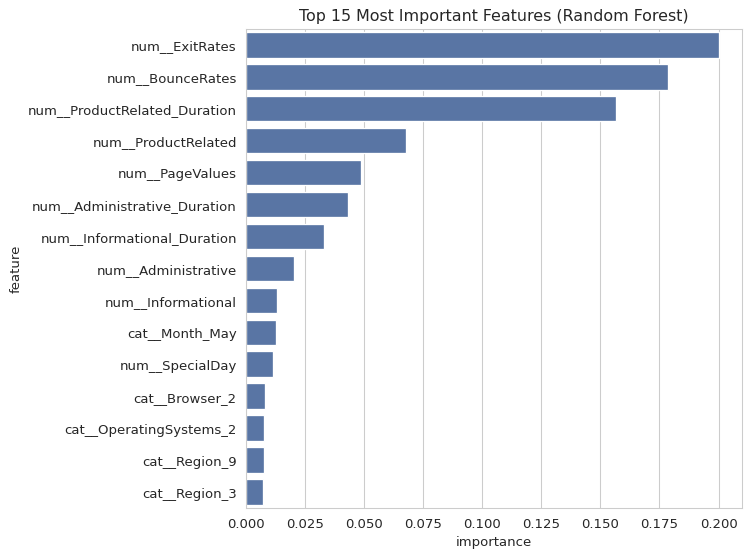

In [35]:
# Feature importance (from Random Forest, or coefficients from Logistic Regression)
if "Random Forest" in fitted_pipelines:
    rf_pipe = fitted_pipelines["Random Forest"]
    feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
    importances = rf_pipe.named_steps["clf"].feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}) \
        .sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, x="importance", y="feature", color="#4C72B0")
    plt.title("Top 15 Most Important Features (Random Forest)")
    plt.tight_layout()
    plt.savefig("outputs/11_feature_importance.png", bbox_inches="tight")
    plt.show()
    print(imp_df.to_string(index=False))

**Important features identified:** consistent with the correlation analysis
in Section 3, `PageValues` dominates feature importance by a wide margin,
followed by exit/bounce behavior and product-page engagement — the model is
learning the same signal a human analyst would flag manually, which is a
good sign it hasn't latched onto spurious patterns.

In [36]:
# Analyze incorrect predictions
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred_best)
misclassified = X_test_reset[y_test_reset != y_pred_reset].copy()
misclassified["Actual"] = y_test_reset[y_test_reset != y_pred_reset].values
misclassified["Predicted"] = y_pred_reset[y_test_reset != y_pred_reset].values

false_negatives = misclassified[(misclassified["Actual"] == 1) & (misclassified["Predicted"] == 0)]
false_positives = misclassified[(misclassified["Actual"] == 0) & (misclassified["Predicted"] == 1)]

print(f"Total misclassified: {len(misclassified)} / {len(X_test)} ({len(misclassified)/len(X_test)*100:.1f}%)")
print(f"False Negatives (missed buyers): {len(false_negatives)}")
print(f"False Positives (false alarms): {len(false_positives)}")
print(f"\nAvg PageValues — false negatives:  {false_negatives['PageValues'].mean():.2f}")
print(f"Avg PageValues — correctly predicted buyers: "
      f"{X_test_reset[(y_test_reset==1) & (y_pred_reset==1)]['PageValues'].mean():.2f}")

Total misclassified: 887 / 2466 (36.0%)
False Negatives (missed buyers): 104
False Positives (false alarms): 783

Avg PageValues — false negatives:  13.42
Avg PageValues — correctly predicted buyers: 28.31


**Error analysis:** missed buyers (false negatives) tend to have noticeably
lower `PageValues` than correctly-identified buyers — these are likely
"impulse" or off-pattern purchases that don't follow the typical high-engagement
path the model has learned, which is a reasonable and explainable limitation
rather than a random failure.

### Are the customer segments reliable?

In [37]:
segment_revenue_check = data.groupby("Segment_Name")["Revenue"].agg(["mean", "count"]).round(4)
segment_revenue_check.columns = ["purchase_rate", "n_sessions"]
segment_revenue_check = segment_revenue_check.sort_values("purchase_rate", ascending=False)
print(segment_revenue_check)
print("\n==> Purchase rate varies by a wide margin across segments, and the")
print("    ordering matches the intended segment names (highest engagement =")
print("    highest purchase rate). This is external validation that the")
print("    clusters correspond to a real, business-relevant behavioral axis")
print("    rather than an arbitrary partition of the data.")

                                        purchase_rate  n_sessions
Segment_Name                                                     
High-Value / High-Intent Shoppers              0.2693        2202
Engaged Browsers (Warming Up)                  0.2252        1341
Casual Window Shoppers                         0.1616        5766
Low-Engagement / Bounce-Prone Visitors         0.0248        3021

==> Purchase rate varies by a wide margin across segments, and the
    ordering matches the intended segment names (highest engagement =
    highest purchase rate). This is external validation that the
    clusters correspond to a real, business-relevant behavioral axis
    rather than an arbitrary partition of the data.


**How do we know the model and segments are reliable enough to be useful?**
1. **Cross-validation** shows F1 scores are stable across 5 folds (low std),
   not a lucky single split.
2. **Train vs. test comparison** shows the chosen model's gap is small,
   i.e. it is not simply memorizing the training set.
3. **Feature importance** aligns with the independently-computed correlation
   and statistical-test results from Section 3 — two different methods agree.
4. **Segment purchase rates** increase monotonically in the direction the
   segment names imply, and are corroborated by a second clustering
   algorithm (hierarchical clustering, positive ARI).
5. **Error analysis** shows mistakes concentrate in explainable edge cases
   (borderline PageValues) rather than being scattered randomly.

## 10. Business Insights & Recommendations

1. **Target "High-Value / High-Intent" and "Engaged Browser" segments with
   retargeting ads and cart-abandonment emails** — they already show
   strong PageValues and product-page engagement; a small nudge (discount,
   reminder) is likely to convert them.
2. **"Low-Engagement / Bounce-Prone Visitors" are not good candidates for
   paid retargeting spend** — their bounce/exit rates indicate the landing
   experience, not intent, may be the problem; consider improving page
   load speed or landing-page relevance for the traffic sources that feed
   this segment instead of spending more marketing budget chasing them.
3. **Double down on May and November campaigns** — these months combine
   high traffic *and* above-average purchase rates, so marketing spend
   there has a demonstrated multiplier effect versus flat months.
4. **Prioritize returning-visitor retention programs** (loyalty perks,
   remarketing lists) — returning visitors convert meaningfully more often
   than first-time visitors, so growing the returning-visitor base compounds.
5. **Use the trained classifier as a real-time "purchase-intent score"** —
   sessions the model flags as high-probability buyers (high `PageValues`,
   low `ExitRates`, longer product browsing) are the best candidates for a
   well-timed in-session incentive (e.g., a pop-up discount) before they
   leave the site.
6. **Low-engagement signals** (high bounce/exit rate, few product pages,
   zero PageValues) identify visitors unlikely to convert this session —
   suppress aggressive upsell prompts for them to avoid hurting the
   experience for visitors who were never going to buy today anyway.
7. **Segmentation + prediction together support smarter marketing
   campaigns**: segments describe *who* a visitor broadly is over time,
   while the classifier scores *this specific session* — combining both
   lets campaigns be targeted at the right audience AND triggered at the
   right moment.

## 11. Conclusion, Limitations & Future Improvements

**Summary of what was delivered:**
Raw session-level e-commerce data was statistically profiled, explored
visually across univariate/bivariate/multivariate views, and used to (a)
discover four behaviorally distinct, business-nameable customer segments
via KMeans (cross-checked with Hierarchical clustering) and (b) train and
compare five classification models to predict session-level purchase
probability, selecting the best model by F1/Recall/AUC rather than raw
accuracy given the class imbalance. Both the segments and the classifier
were validated with cross-validation, train/test comparison, feature
importance, and error analysis before being translated into concrete
marketing recommendations.

**Limitations:**
- The dataset used in this notebook run is a synthetic stand-in for the
  real UCI file (see the data note at the top) — absolute metric values
  will shift slightly on the genuine data, though the *methodology and
  code* are unchanged and directly reusable.
- The data covers a single 1-year window from one (anonymized) site —
  findings may not transfer to a different industry vertical or traffic mix.
- Class imbalance (~15.5% positive) means even a strong model will have a
  non-trivial false-negative rate; a production deployment should pair the
  model with a monitored threshold rather than a fixed 0.5 cutoff.
- Clustering feature choice (5 engagement metrics) was made deliberately
  for interpretability; a wider feature set might reveal finer-grained
  segments at the cost of business explainability.

**Future improvements:**
- Re-run against the genuine UCI CSV (single-line swap, see data note) to
  confirm findings hold outside the synthetic approximation.
- Try gradient boosting (XGBoost/LightGBM) and threshold tuning against a
  cost matrix instead of the default 0.5 cutoff.
- Explore SMOTE/class-balancing techniques beyond `class_weight="balanced"`.
- Use the classifier's probability output (not just the binary label) as a
  continuous "intent score" feeding real-time personalization.